<a id="toc"></a>
<p><center style="color:pink; font-family: 'Pacifico', cursive; font-size:25px;">Welcome back to my work </center></p>

<div style="background-color:white; padding: 2px;">
<div class="alert alert-block alert-secondary" style="font-size:35px; font-family:'Merriweather'; text-align:center">  ⚡Complete Guide to 🧠Stress Detection using 🔬PPG Signals & Advanced ML</div></div>

<div>

 <h1 align="left"><font color=pink>Table of Contents</font></h1></div>
 
<a id="toc"></a>
- [ 1 - Getting Started ](#1)
- [ 2 - Pre-Visualization and Data Split](#2)
- [ 3 - Train Test Split](#3)
- [ 4 - Random Forest Clssifier](#4)
- [ 5 - SVM Classifier](#5)

### 📋 What is This Tutorial all about?
<!--
***This notebook is in continuation of Part-I: Signal Processing and Feature Engineering***


You can first visit <a href="https://www.kaggle.com/code/krishd123/stress-detection-ppg-signals-features" target="_blank">`Stress Detection: PPG Signals & EMD Features'</a> to understand how the below mentioned second dataset is being created and will be used ahead in this notebook.

You must be aware about my following datasets to understand better -
- <a href="https://www.kaggle.com/datasets/krishd123/ppg-collection-for-cognitive-strain" target="_blank">Input - PPG Collection</a>
- <a href="https://www.kaggle.com/datasets/krishd123/emd-based-ppg-features" target="_blank">Produced - EMD Based PPG Features</a>

I hope, you learn from this session!
-->

This notebook is a continuation of **Part I: Signal Processing and Feature Engineering**.  
👉 You may first check out the previous notebook for context:  
[`Stress Detection: PPG Signals & EMD Features`](https://www.kaggle.com/code/krishd123/stress-detection-ppg-signals-features)

The datasets used here:  

- 📥 [**Input Dataset – PPG Collection**](https://www.kaggle.com/datasets/krishd123/ppg-collection-for-cognitive-strain)  
- ⚙️ [**Feature Dataset – EMD Based PPG Features**](https://www.kaggle.com/datasets/krishd123/emd-based-ppg-features)

You should be aware about them to understand better.

💡 **Goal**: Build and evaluate machine learning models for stress detection using PPG-derived features.  

I hope, you learn from this session!

---

<a id="1"></a>
# <b><span style='color:pink'>Getting Started</span></b> 

## Import / Load

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import skew

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
ORG_DATA_PATH = "/kaggle/input/ppg-collection-for-cognitive-strain"
FEATURE_DATA_PATH = "/kaggle/input/emd-based-ppg-features"

# From the second dataset mentioned above, we will load the statistical data for the first two IMFs
df = pd.read_csv("/kaggle/input/emd-based-ppg-features/emd_2_imfs.csv")


# Quick preview
print("Dataset Preview:")
display(df.head())

Dataset Preview:


,Set_no,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Imf_2_MEAN,Imf_2_MIN,Imf_2_MAX,Imf_2_SKEWNESS,Label
0,1,-0.019833,-0.759453,0.669737,-0.291265,0.065305,-0.780511,0.828957,-0.141385,0
1,2,-0.000523,-0.483545,0.372808,-0.095509,-0.017183,-0.469677,0.444079,-0.003685,0
2,3,-0.002994,-0.515715,0.477036,-0.135352,-0.018993,-0.534292,0.466072,0.150989,0
3,4,-0.064826,-1.125280,0.763962,-0.330766,-0.004048,-0.384278,0.378492,-0.006008,0
4,5,-0.048414,-0.666120,0.516938,-0.006708,-0.011566,-0.208379,0.230606,0.161022,0


## Data Overview and Quality Checks

In [3]:
print("\n📐 Shape of dataset:", df.shape)
print("\nℹ️ Dataset Info:")
df.info()


📐 Shape of dataset: (8800, 10)

ℹ️ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Set_no          8800 non-null   int64  
 1   Imf_1_MEAN      8800 non-null   float64
 2   Imf_1_MIN       8800 non-null   float64
 3   Imf_1_MAX       8800 non-null   float64
 4   Imf_1_SKEWNESS  8800 non-null   float64
 5   Imf_2_MEAN      8800 non-null   float64
 6   Imf_2_MIN       8800 non-null   float64
 7   Imf_2_MAX       8800 non-null   float64
 8   Imf_2_SKEWNESS  8800 non-null   float64
 9   Label           8800 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 687.6 KB


In [4]:
print("\n📈 Descriptive Statistics:")
display(df.describe())


📈 Descriptive Statistics:


,Set_no,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Imf_2_MEAN,Imf_2_MIN,Imf_2_MAX,Imf_2_SKEWNESS,Label
count,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000
mean,4400.500000,-0.040408,-1.078599,0.999876,-0.021059,-0.029379,-0.903992,0.908268,0.104376,0.500000
std,2540.485518,0.103832,0.662280,0.656826,0.253064,0.071523,0.551611,0.545112,0.164084,0.500028
min,1.000000,-0.952494,-28.930280,0.057970,-1.832723,-0.854351,-19.244218,-0.486920,-2.077835,0.000000
25%,2200.750000,-0.072856,-1.089867,0.738294,-0.191839,-0.035954,-0.979125,0.683812,0.067046,0.000000
50%,4400.500000,-0.017616,-1.088727,0.842253,-0.036290,-0.035297,-0.845880,0.841740,0.134909,0.500000
75%,6600.250000,0.033751,-0.771923,1.062066,0.059352,-0.017271,-0.653248,0.968052,0.176348,1.000000
max,8800.000000,0.819490,-0.056660,24.980012,2.089826,1.900942,0.761834,23.338821,1.338933,1.000000


In [5]:
print("\n❓ Missing Values per Column:")
display(df.isna().sum())

if "Label" in df.columns:
    print("\n⚖️ Class Distribution:")
    display(df["Label"].value_counts(normalize=True))


❓ Missing Values per Column:


Set_no            0
Imf_1_MEAN        0
Imf_1_MIN         0
Imf_1_MAX         0
Imf_1_SKEWNESS    0
Imf_2_MEAN        0
Imf_2_MIN         0
Imf_2_MAX         0
Imf_2_SKEWNESS    0
Label             0
dtype: int64


⚖️ Class Distribution:


Label
0    0.5
1    0.5
Name: proportion, dtype: float64

<a id="toc"></a>

<a href="#toc" style="background-color: blue; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="2"></a>
# <b><span style='color:pink'>Pre- Visualization and Data Split</span></b> 

#### Split data by label

In [6]:
df_stress0=df[df.Label==0]     # Low Stress
df_stress0.head()

,Set_no,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Imf_2_MEAN,Imf_2_MIN,Imf_2_MAX,Imf_2_SKEWNESS,Label
0,1,-0.019833,-0.759453,0.669737,-0.291265,0.065305,-0.780511,0.828957,-0.141385,0
1,2,-0.000523,-0.483545,0.372808,-0.095509,-0.017183,-0.469677,0.444079,-0.003685,0
2,3,-0.002994,-0.515715,0.477036,-0.135352,-0.018993,-0.534292,0.466072,0.150989,0
3,4,-0.064826,-1.125280,0.763962,-0.330766,-0.004048,-0.384278,0.378492,-0.006008,0
4,5,-0.048414,-0.666120,0.516938,-0.006708,-0.011566,-0.208379,0.230606,0.161022,0


In [7]:
df_stress1=df[df.Label==1]     # High Stress
df_stress1.head()

,Set_no,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Imf_2_MEAN,Imf_2_MIN,Imf_2_MAX,Imf_2_SKEWNESS,Label
4400,4401,0.040093,-0.647498,0.686118,0.029075,-0.056848,-1.327420,1.250371,0.038183,1
4401,4402,0.073511,-1.388993,1.714738,0.519303,-0.063517,-1.114362,1.299404,0.334970,1
4402,4403,-0.010257,-0.948975,0.924290,-0.015019,0.014412,-0.712370,0.753879,-0.056010,1
4403,4404,-0.018021,-0.503284,0.459044,-0.047670,-0.005253,-0.496433,0.397082,0.035819,1
4404,4405,-0.054674,-0.611935,0.749980,0.255805,-0.028684,-0.271311,0.271184,0.261495,1


In [8]:
print("🔹 Non-stress samples:", df_stress0.shape[0])
print("🔹 Stress samples:", df_stress1.shape[0])

🔹 Non-stress samples: 4400
🔹 Stress samples: 4400


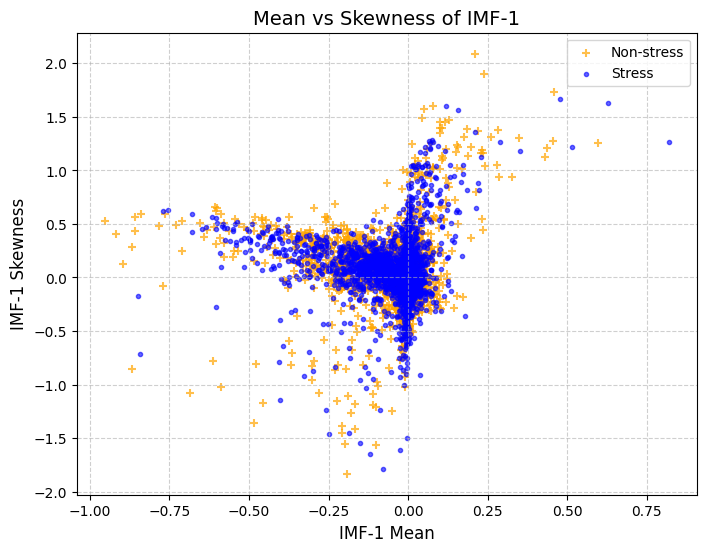

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_stress0["Imf_1_MEAN"], df_stress0["Imf_1_SKEWNESS"],
    color="orange", marker="+", alpha=0.7, label="Non-stress"
)
plt.scatter(
    df_stress1["Imf_1_MEAN"], df_stress1["Imf_1_SKEWNESS"],
    color="blue", marker=".", alpha=0.6, label="Stress"
)

plt.title("Mean vs Skewness of IMF-1", fontsize=14)
plt.xlabel("IMF-1 Mean", fontsize=12)
plt.ylabel("IMF-1 Skewness", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

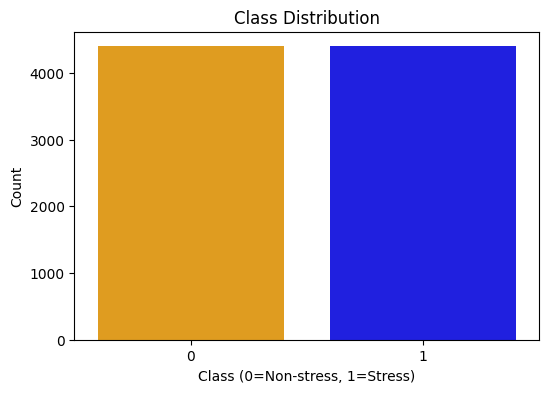

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, palette={0: "orange", 1: "blue"})
plt.title("Class Distribution")
plt.xlabel("Class (0=Non-stress, 1=Stress)")
plt.ylabel("Count")
plt.show()

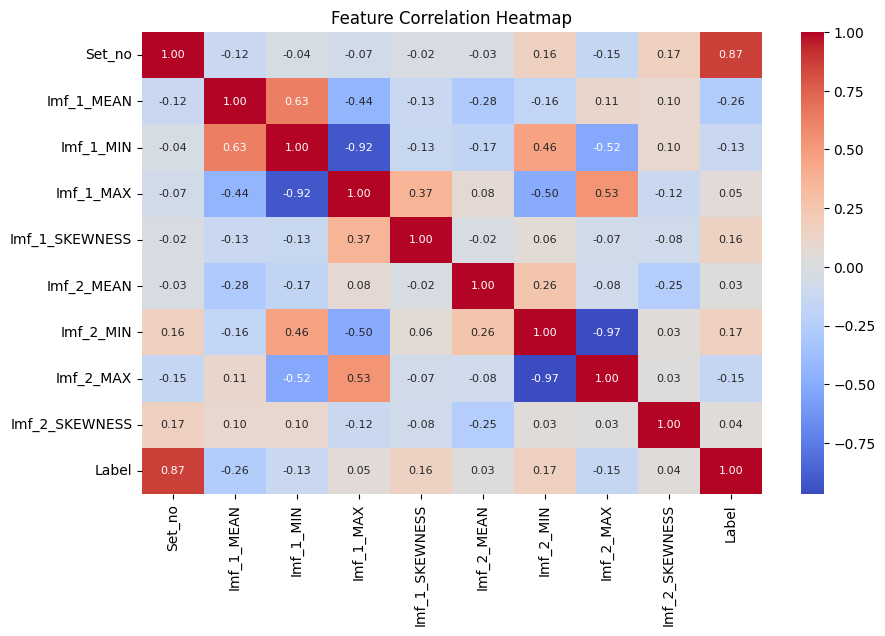

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(),
    annot=True,        # show correlation values
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",
    cbar=True,
    annot_kws={"size": 8}  # smaller font for readability
)
plt.title("Feature Correlation Heatmap")
plt.show()

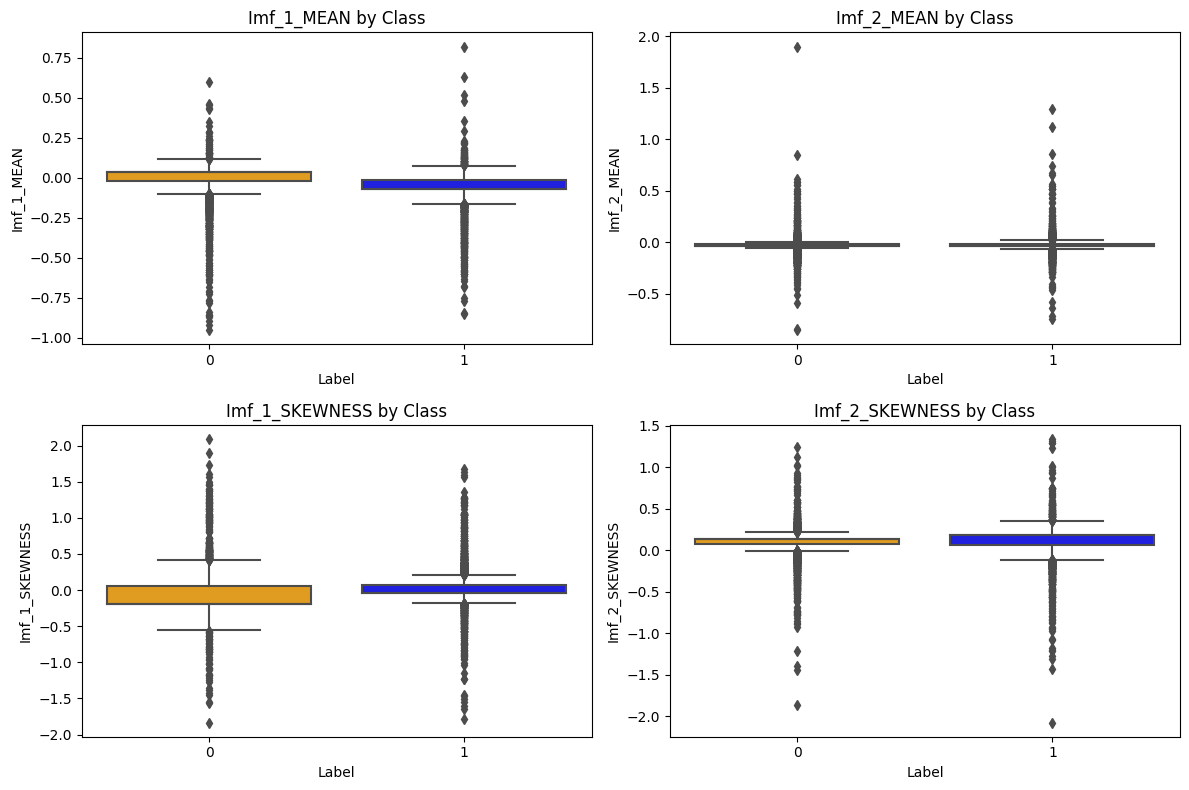

In [12]:
# Boxplots of Selected Features by Label
selected_features = ["Imf_1_MEAN", "Imf_2_MEAN", "Imf_1_SKEWNESS", "Imf_2_SKEWNESS"]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="Label", y=feature, data=df, palette={0: "orange", 1: "blue"})
    plt.title(f"{feature} by Class")
plt.tight_layout()
plt.show()

#### Feature & Target Split

In [13]:
X = df.iloc[:, 1:9]   # Independent features
y = df["Label"]       # Target variable

print("\n🧩 Features (X):")
display(X.head())

print("\n🎯 Target (y):")
display(y.sample(5))


🧩 Features (X):


,Imf_1_MEAN,Imf_1_MIN,Imf_1_MAX,Imf_1_SKEWNESS,Imf_2_MEAN,Imf_2_MIN,Imf_2_MAX,Imf_2_SKEWNESS
0,-0.019833,-0.759453,0.669737,-0.291265,0.065305,-0.780511,0.828957,-0.141385
1,-0.000523,-0.483545,0.372808,-0.095509,-0.017183,-0.469677,0.444079,-0.003685
2,-0.002994,-0.515715,0.477036,-0.135352,-0.018993,-0.534292,0.466072,0.150989
3,-0.064826,-1.125280,0.763962,-0.330766,-0.004048,-0.384278,0.378492,-0.006008
4,-0.048414,-0.666120,0.516938,-0.006708,-0.011566,-0.208379,0.230606,0.161022



🎯 Target (y):


7383    1
2565    0
4773    1
7295    1
8706    1
Name: Label, dtype: int64

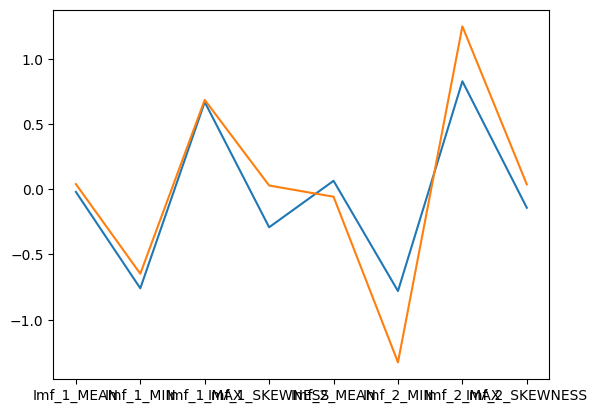

In [14]:
plt.plot(X.iloc[0])
plt.plot(X.iloc[4400])

---

<a id="toc"></a>

<a href="#toc" style="background-color: blue; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="3"></a>
# <b><span style='color:pink'>Train Test Split</span></b> 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

<a id="toc"></a>

<a href="#toc" style="background-color: blue; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4"></a>
# <b><span style='color:pink'>Random Forest Classifier</span></b> 

In [16]:
classifier = RandomForestClassifier(n_estimators = 1000)
classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000)

In [17]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 1, 1, ..., 0, 0, 0])

In [18]:
print ("Accuracy : ", accuracy_score(y_test, y_pred)*100)

Accuracy :  81.04545454545455


In [19]:
conf = confusion_matrix(y_test, y_pred)
print ("Confusion Matrix : \n", conf)

Confusion Matrix : 
 [[865 194]
 [223 918]]


In [20]:
rec = conf[0][0]/(conf[0][0]+conf[1][0])
print("Recall : \n",rec)

Recall : 
 0.7950367647058824


In [21]:
prec = conf[0][0]/(conf[0][0]+conf[0][1])
print("Precision:\n",prec)

Precision:
 0.8168083097261567


<a id="toc"></a>

<a href="#toc" style="background-color: blue; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="5"></a>
# <b><span style='color:pink'>Support Vector Machine (SVM) Classifier</span></b> 

In [22]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [23]:
model.score(X_test, y_test)

0.8022727272727272

### Kernalization

In [24]:
model_kernal = SVC(kernel='sigmoid')
model_kernal.fit(X_train, y_train)

model_kernal.score(X_test, y_test)*100

74.81818181818181

### Regularization (C)

In [25]:
model_C = SVC(C=200)
model_C.fit(X_train, y_train)
model_C.score(X_test, y_test)*100

82.18181818181817

In [26]:
y_prd = model_C.predict(X_test)
y_prd

array([1, 1, 1, ..., 0, 1, 0])

In [27]:
cm = confusion_matrix(y_test, y_prd)
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[886 173]
 [219 922]]


In [28]:
prec = cm[0][0]/(cm[0][0]+cm[0][1])
print("Precision:\n",prec)

Precision:
 0.8366383380547686


In [29]:
rec = cm[0][0]/(cm[0][0]+cm[1][0])
print("Recall : \n",rec)

Recall : 
 0.8018099547511313


---

<p><center  style="font-family:Gabriola;color:blue;text-align:center; font-size:160%;">🤗 If you find this notebook interesting💡 or of any help, then <font style="font-family:Gabriola;text-align:center; color:green; font-size: 100%;"> GO and EXPERIMENT ↗️ </font><font style="font-family:Gabriola;color:blue;text-align:center; font-size:100%;">with it and pen down🖍️ your thoughts in comments</font>  </center></p>

---